# Two steps neural network 
Time and diffusive parameters

In [14]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
from itertools import product
import keras
import tensorflow as tf

In [15]:
# reproducibility
seed=42
np.random.seed(seed)

keras.utils.set_random_seed(seed)

tf.random.set_seed(seed)

## Data preparation

In [16]:
file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations_time.txt")

Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)


In [17]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, t_HF_test) = import_data(file_path_HF)
t_HF_test=t_HF_test.T
U_HF_test = U_HF_test[:, :, 44,44]

In [18]:
########################     NORMALIZATION  #########################
# Input

reaction_HF_test = normalization(reaction_HF_test)
t_HF_test=normalization(t_HF_test)
U_HF_test=normalization(U_HF_test)


In [19]:
#########################     TRAIN SET      ##########################
NepoLF = 1000  # number of epochs for first NN: NN_LF
NepoHF = 500  # number of epochs for second NN: NN_HF

Nlf = np.array([100,150,200])
n_HF=np.array([50,75,100,150])

In [20]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(t_HF_test))

#reaction_HF = reaction_HF_test[permutation1][0:n_HF]
#t_HF = t_HF_test[permutation2][0:n_HF]

#grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
#reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), t_HF_test.flatten())))


#reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(3*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]


##
#p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
#permutation = np.column_stack((p1.ravel(), p2.ravel()))
#U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test2 = U_HF_test.flatten()[comb]
##

In [21]:
U_LF_list = []
U_HF_list = []

diffusion=[5]

r2_HF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','MSE'])  # dataframe which stores LF MSE

********************  # Nb. nodes = 801  ********************
********************  # NLH = 50  ********************
********************  # NLF = 100  ********************
********************  # Diff: = 5  ********************


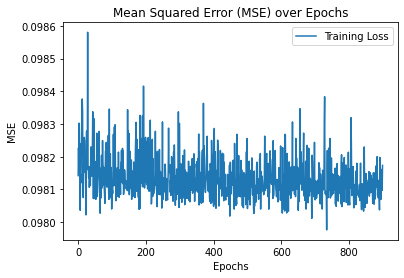

1252/1252 [==============================] - 2s 2ms/step

LF Model:
Test MSE: 0.1018412336685309
R^2: -0.0035351925797884043
313/313 [==============================] - 1s 2ms/step


ValueError: Data cardinality is ambiguous:
  x sizes: 10000
  y sizes: 2500
Make sure all arrays contain the same number of samples.

In [22]:
test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []


#############à
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
                file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_46"+"_d"+str(diffusion[d])+"_t"+str(Discretizations[m])+".mat")

                (reaction_LF_test, U_LF_test, t_LF_test) = import_data(file_name)
                t_LF_test=t_LF_test.T
                U_LF_test = U_LF_test[
                :,
                :,
                int(4*(Discretizations[m]-1)/9),
                int(4*(Discretizations[m]-1)/9)
                ]
                reaction_HF = reaction_HF_test[permutation1][0:nhf]
                t_HF = t_HF_test[permutation2][0:nhf]
                grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
                reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
                reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
                
                p1, p2 = np.meshgrid(permutation1[0:nhf], permutation2[0:nhf])
                permutation = np.column_stack((p1.ravel(), p2.ravel()))
                U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 

                reaction_LF_test = normalization(reaction_LF_test)
                t_LF_test = normalization(t_LF_test)
                U_LF_test = normalization(U_LF_test)
                
                print(
                f"********************  # Nb. nodes = {t_LF_test.shape[0]}  ********************"
                )
                print(
                f"********************  # NLH = {nhf}  ********************"
                )
                print(
                f"********************  # NLF = {nlf}  ********************"
                )
                
                
                
                ######### DATASET
                L=np.minimum(nlf,t_LF_test.shape[0])
                permutation1 = np.random.permutation(len(reaction_LF_test))
                permutation2 = np.random.permutation(len(t_LF_test))
                reaction_LF = reaction_LF_test[permutation1][0:L]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
                t_LF = t_LF_test[permutation2][0:L]
                
                grid1, grid2 = np.meshgrid(reaction_LF, t_LF)
                reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))   # <--------
                reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), t_LF_test.flatten())))
                
                #
                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(3*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(3*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]
                #
                
                p1, p2 = np.meshgrid(permutation1[0:L], permutation2[0:L])
                permutation = np.column_stack((p1.ravel(), p2.ravel()))
                U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
                row, col = U_LF_test.shape
                index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
                comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
                U_LF_test = U_LF_test.flatten()[comb]
                #######      

                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                ##########################       FIRST NN: NN_LF     ##########################
                K.clear_session()
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                
                modelLF = getModel(bestLF_params, "LF")  # ann_functions
                histLF = modelLF.fit(
                    reaction_LF, U_train_LF, epochs=NepoLF, batch_size=nlf, verbose=0
                )
                
                plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
                plt.title('Mean Squared Error (MSE) over Epochs')
                plt.xlabel('Epochs')
                plt.ylabel('MSE')
                plt.legend()
                plt.show()


                ULF = modelLF.predict(reaction_LF_test)

                U_LF_list.append(ULF)
                print("\nLF Model:")
                
                test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
                test_mse_LF_list.append(test_mse)
                print(f"Test MSE: {test_mse}")

                r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
                    np.square(U_LF_test - np.mean(U_LF_test))
                )
                r2_LF_list.append(r_2)
                print(f"R^2: {r_2}")
                
                ### SECOND NN#####################
                start = perf_counter()
                reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
                reaction_test_in = np.concatenate(
                (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
                )   # <- TEST INPUT for the second NN: NN_HF

                reaction_train_help = modelLF.predict(reaction_HF)[
                    :, 0
                ]  # f_LF(mu_hf_train)
                reaction_final = np.concatenate(
                (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                name = "2step"
                K.clear_session()
                # best parameters obtained by HPO:

                best_params = {
                    "kernel_init": "uniform",
                    "l2weight": 0.0002588943618918075,
                    "lr": 0.008365144388542751,
                    "nodes": 6.0,
                    "opt": "Adam",
                }
                
                
                finalModel = getModel(
                    best_params, name
                )  # final model chosen according to the best paramters
                hist = finalModel.fit(
                    reaction_final,
                    U_HF,
                    validation_data=(reaction_test_in, U_HF_test2),
                    epochs=NepoHF,
                    batch_size=nhf,
                    verbose=0,
                    validation_freq=20,
                )

                plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
                plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
                plt.xlabel('Epochs')
                plt.ylabel('MSE')
                plt.legend()
                plt.show()

                UHF = finalModel.predict(reaction_test_in)
                U_HF_list.append(UHF)

                stop = perf_counter()
                elapsed = stop - start
                print("Elapsed time: ", elapsed)
                print("\nHF Model:")

                test_mse = np.mean(np.square(U_HF_test2 - UHF[:, 0]))
                test_mse_HF_list.append(test_mse)
                print(f"Test MSE: {test_mse}")

                r2_HF = 1 - np.sum(np.square(U_HF_test2 - UHF[:, 0])) / np.sum(
                    np.square(U_HF_test2 - np.mean(U_HF_test2))
                )
                r2_HF_list.append(r2_HF)
                print(f"R^2: {r2_HF}")
                
                ### plot
                plt.figure()
                mask1_test=np.where(reaction_test_in[:,0]==np.min(reaction_test_in[:,0]))
                mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
                mask1_LF=np.where(reaction_LF[:,0]==np.min(reaction_LF[:,0]))
                order=np.argsort(reaction_LF[mask1_LF,1])


                plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test2[mask1_test], "r-", linewidth=1.5, label="HF model")
                plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
                plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
                plt.plot(
                reaction_test_in[mask1_test, 1].T,
                finalModel.predict(reaction_test_in[mask1_test, :][0,:,:]),
                "g-",
                markersize=5,
                label="Predicted HF model",
                )

                plt.legend(prop={"size": 8.3})  
                plt.title("time variation")
                plt.show()
        #---------------------------
                plt.figure()
                mask2_test=np.where(reaction_test_in[:,1]==np.min(reaction_test_in[:,1]))
                mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))   
                mask2_LF=np.where(reaction_LF[:,1]==np.min(reaction_LF[:,1]))
                order=np.argsort(reaction_LF[mask2_LF,0])

                plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test2[mask2_test], "r-", linewidth=1.5, label="HF model")
                plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
                plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]][:,0], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
                plt.plot(
                reaction_test_in[mask2_test, 0].T,
                finalModel.predict(reaction_test_in[mask2_test, :][0,:,:]),
                "g-",
                markersize=5,
                label="Predicted HF model",
                )
                
                plt.legend(prop={"size": 8.3})
                plt.title("mu variation")
                plt.show()

                new = {'Discretization': Discretizations[m], 'R2': r2_LF_list[-1]}
                r2_LF_df=r2_LF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'R2': r2_HF_list[-1]}
                r2_HF_df=r2_HF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'MSE': test_mse_LF_list[-1]}
                mse_LF_df=mse_LF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'MSE': test_mse_HF_list[-1]}
                mse_HF_df=mse_HF_df.append(new, ignore_index=True)
                
                if not r2_HF_list[:-1]:
                    save_model(modelLF,"modelLF2NN.h5")
                    save_model(finalModel,"finalModel2NN.h5")
                elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                    save_model(modelLF,"modelLF2NN.h5")
                    save_model(finalModel,"finalModel2NN.h5")
                
        print(r2_HF_df.round(5))
        print(mse_HF_df.round(5))


In [34]:
print(reaction_HF_test.shape)
reaction_HF = reaction_HF_test[permutation1][0:nhf]
print(reaction_HF.shape)
t_HF = t_HF_test[permutation2][0:nhf]
grid1, grid2 = np.meshgrid(reaction_HF, t_HF)
print(grid1.shape)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
print(reaction_HF.shape)
reaction_HF=np.c_[reaction_HF, np.abs(np.sin(3*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
print(reaction_HF.shape)


(40050, 4)
(50, 4)
(50, 200)
(10000, 2)
(10000, 4)


In [ ]:
print(U_HF_test.shape)

(40050,)


[    0 27234 28035 ... 21626 19223 40049]
(array([    0,   801,  1602,  2403,  3204,  4005,  4806,  5607,  6408,
        7209,  8010,  8811,  9612, 10413, 11214, 12015, 12816, 13617,
       14418, 15219, 16020, 16821, 17622, 18423, 19224, 20025, 20826,
       21627, 22428, 23229, 24030, 24831, 25632, 26433, 27234, 28035,
       28836, 29637, 30438, 31239, 32040, 32841, 33642, 34443, 35244,
       36045, 36846, 37647, 38448, 39249], dtype=int64),)
(array([1300, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 1310,
       1311, 1312, 1313, 1314, 1315, 1316, 1317, 1318, 1319, 1320, 1321,
       1322, 1323, 1324, 1325, 1326, 1327, 1328, 1329, 1330, 1331, 1332,
       1333, 1334, 1335, 1336, 1337, 1338, 1339, 1340, 1341, 1342, 1343,
       1344, 1345, 1346, 1347, 1348, 1349], dtype=int64),)
(array([72, 73, 74, 75, 76, 77, 78, 79, 80], dtype=int64),)
2/2 [==============================] - 0s 3ms/step
[0.      0.00125 0.0025  0.00375 0.005   0.00625 0.0075  0.00875 0.01
 0.01125 0.0125 

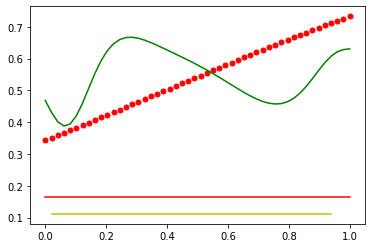

In [ ]:
index_order=np.argsort(reaction_test_in[:,1])
mask2_test=np.where(reaction_test_in[:,1]==reaction_test_in[:,1][index_order[2]])
mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))
index_order_LF=np.argsort(reaction_LF[:,1])   
mask2_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
order=np.argsort(reaction_LF[mask2_LF,0])
print(np.argsort(reaction_test_in[:,1]))

print(mask2_test)
print(mask2)
print(mask2_LF)

plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]][:,0], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
plt.plot(
reaction_test_in[mask2_test, 0].T,
finalModel.predict(reaction_test_in[mask2_test, :][0,:,:]),
"g-",
markersize=5,
label="Predicted HF model",
)

print(np.unique(reaction_test_in[:,1]))
print(np.min(reaction_final[:,1]))
print(np.max(reaction_LF[:,1]))

## Save the output

In [ ]:
os.makedirs("MF_LF_150_5000_HF_75_4000_2NNt_multiparam")

r2_HF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_150_5000_HF_75_4000_2NNt_multiparam/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)